In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
def func(t,y):
  return y - t**2 + 1


def real_func(t):
    return (t+1)**2 - 0.5*np.exp(t)

In [3]:
class discret_methods:
    def __init__(self,ti,tf,y0,h,func,real_func):
        self.ti = ti
        self.tf = tf
        self.y0 = y0
        self.h = h
        self.func = func
        self.real_func = real_func
        self.N = int(np.ceil((tf - ti)/h))

    def euler_explicito(self):
        y = np.zeros(self.N + 1)
        t = np.zeros(self.N + 1)
        t[0] = self.ti
        y[0] = self.y0
        for i in range(self.N):
            y[i + 1] = y[i] + self.h*self.func(t[i],y[i])
            t[i + 1] = t[i] + self.h
        return t,y

    def real_plot(self):
        t = np.linspace(self.ti,self.tf)
        y = self.real_func(t)
        plt.plot(t,y, label = "Real function", linestyle = "--")

    def heun(self):
        y = np.zeros(self.N + 1)
        t = np.zeros(self.N + 1)
        t[0] = self.ti
        y[0] = self.y0
        for i in range(self.N):
            t[i  + 1] = t[i] + self.h
            k1 = self.func(t[i], y[i])
            y_m = y[i] + self.h*k1
            k2 = self.func(t[i + 1], y_m)
            k = (k1 + k2) / 2
            y[i + 1] = y[i] + self.h*k
        return t,y

    def runge_kutta_4(self):
        t = np.zeros(self.N + 1)
        y = np.zeros(self.N + 1)
        y[0] = self.y0
        t[0] = self.ti
        for i in range(self.N):
            k1 = self.h*self.func(t[i],y[i])
            k2 = self.h*self.func(t[i] + self.h/2, y[i] + (1/2)*k1)
            k3 = self.h*self.func(t[i] + self.h/2, y[i] + (1/2)*k2)
            t[i + 1] = t[i] + self.h
            k4 = self.h*func(t[i + 1],y[i] + k3)
            y[i + 1] = y[i] + (1/6)*(k1 + 2*k2 + 2*k3 + k4)
        return t,y

    def aprox_plot(self):
        t1,y1 = self.heun()
        t2,y2 = self.euler_explicito()
        t3,y3 = self.runge_kutta_4()
        plt.plot(t2,y2,'bo-',label = "Euler")
        plt.plot(t3,y3,'k--',label = "Runge-kutta 4")
        plt.plot(t1,y1,label = "Heun")
        self.real_plot()
        plt.legend()
        plt.grid()
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.show()
        return y1,y2,y3


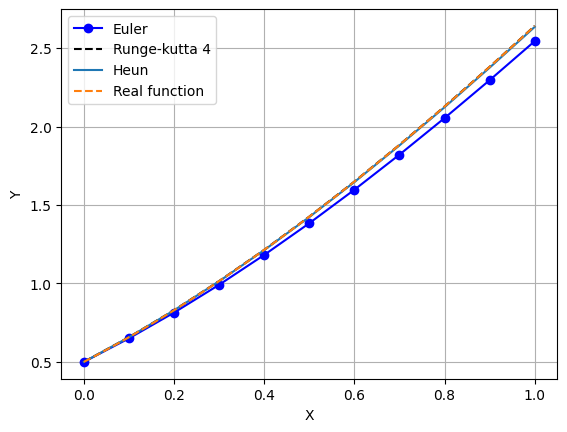

,0,1,2,3,4,5,6,7,8,9,10
Heun,0.5,0.657000,0.828435,1.013721,1.212211,1.423194,1.645879,1.879396,2.122783,2.374975,2.634797
Euler,0.5,0.650000,0.814000,0.991400,1.181540,1.383694,1.597063,1.820770,2.053847,2.295231,2.543755
Runge-kutta 4,0.5,0.657414,0.829298,1.015070,1.214087,1.425638,1.648939,1.883122,2.127228,2.380196,2.640857


In [4]:
exerc1 = discret_methods(0,1,0.5,0.1,func,real_func)
tab = exerc1.aprox_plot()
tabela = pd.DataFrame(tab, index = ["Heun", "Euler", "Runge-kutta 4"])
tabela

Exercício 2

In [5]:
def func(t,y):
    return np.cos(2*t) + np.sin(3*t)
def real_function(t):
    return (1/2)*np.sin(2*t) -(1/3)*np.cos(3*t) + 4/3

In [6]:
h = [0.5,0.25,0.125,0.0625,0.03125]

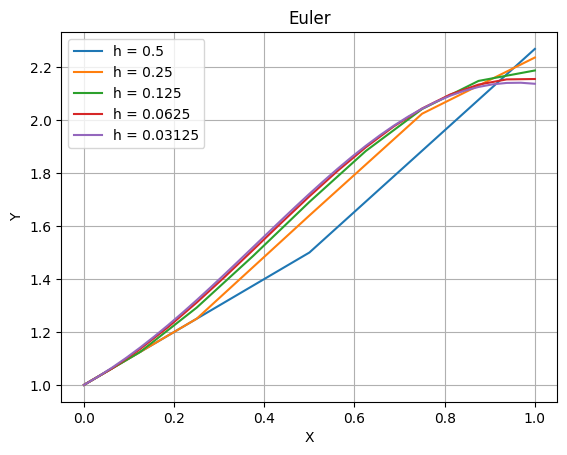

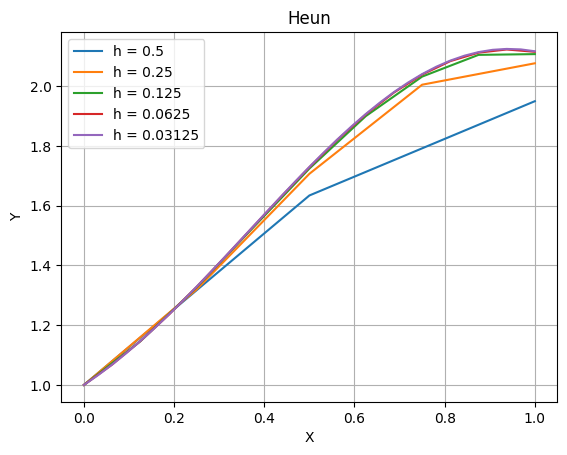

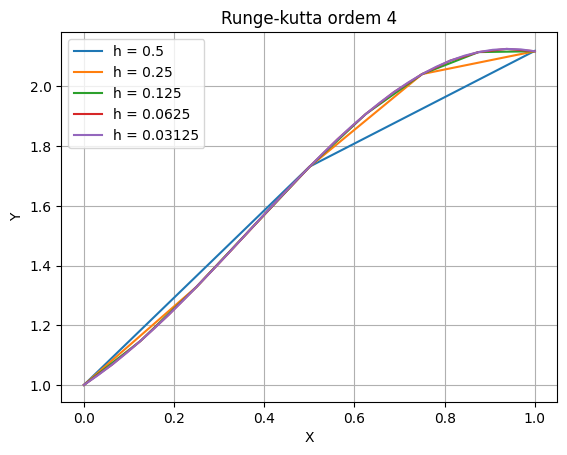

In [7]:
norm_euler = np.zeros(len(h))
norm_heun = np.zeros(len(h))
norm_runge = np.zeros(len(h))

for i in range(len(h)):
    exerc2 = discret_methods(0,1,1,h[i],func,real_function)
    t1,y1 = exerc2.euler_explicito()
    norm_euler[i] = (h[i]*np.sum((real_function(t1) - y1)**2))**(1/2)
    plt.plot(t1,y1,label = f"h = {h[i]}")
plt.grid()
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title("Euler")
plt.show()
for i in range(len(h)):
    exerc2 = discret_methods(0,1,1,h[i],func,real_function)
    t1,y1 = exerc2.heun()
    norm_heun[i] = (h[i]*np.sum((real_function(t1) - y1)**2))**(1/2)
    plt.plot(t1,y1,label = f"h = {h[i]}")
plt.grid()
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title("Heun")
plt.show()
for i in range(len(h)):
    exerc2 = discret_methods(0,1,1,h[i],func,real_function)
    t1,y1 = exerc2.runge_kutta_4()
    norm_runge[i] = (h[i]*np.sum((real_function(t1) - y1)**2))**(1/2)
    plt.plot(t1,y1,label = f"h = {h[i]}")
plt.grid()
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title("Runge-kutta ordem 4")
plt.show()